<a href="https://colab.research.google.com/github/zhannakakenova/KBU-Zhanna-Spring/blob/main/0404lesson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import shapiro
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import re

In [16]:
url = "http://books.toscrape.com/"

response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

books = soup.find_all("h3")

titles = []

for book in books:
    title = book.find("a")["title"]
    titles.append(title)

df_20 = pd.DataFrame(titles, columns=["Title"])
df_20

,Title
0,A Light in the Attic
1,Tipping the Velvet
2,Soumission
3,Sharp Objects
4,Sapiens: A Brief History of Humankind
5,The Requiem Red
6,The Dirty Little Secrets of Getting Your Dream...
7,The Coming Woman: A Novel Based on the Life of...
8,The Boys in the Boat: Nine Americans and Their...
9,The Black Maria


In [17]:
titles_all = []

for page in range(1, 6):
    url = f"http://books.toscrape.com/catalogue/page-{page}.html"

    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    books = soup.find_all("h3")

    for book in books:
        title = book.find("a")["title"]
        titles_all.append(title)

df_100 = pd.DataFrame(titles_all, columns=["Title"])
df_100

,Title
0,A Light in the Attic
1,Tipping the Velvet
2,Soumission
3,Sharp Objects
4,Sapiens: A Brief History of Humankind
...,...
95,Lumberjanes Vol. 3: A Terrible Plan (Lumberjan...
96,"Layered: Baking, Building, and Styling Spectac..."
97,Judo: Seven Steps to Black Belt (an Introducto...
98,Join


In [20]:
categories = [
    "travel", "mystery", "historical-fiction", "sequential-art",
    "classics", "philosophy", "romance", "womens-fiction",
    "fiction", "childrens"
]

data = []

categories = [
    "travel_2",
    "mystery_3",
    "historical-fiction_4",
    "sequential-art_5",
    "classics_6",
    "philosophy_7",
    "romance_8",
    "womens-fiction_9",
    "fiction_10",
    "childrens_11"
]

for category in categories:
    url = f"http://books.toscrape.com/catalogue/category/books/{category}/index.html"

    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    books = soup.find_all("article", class_="product_pod")

    print(category, len(books))  # 👈 проверка

    for book in books[:10]:
        title = book.find("h3").find("a")["title"]
        price = book.find("p", class_="price_color").text
        price = float(re.sub(r"[^\d.]", "", price))

        data.append([category, title, price])

df = pd.DataFrame(data, columns=["Category", "Title", "Price"])
df.head()

travel_2 11
mystery_3 20
historical-fiction_4 20
sequential-art_5 20
classics_6 19
philosophy_7 11
romance_8 20
womens-fiction_9 17
fiction_10 20
childrens_11 20


,Category,Title,Price
0,travel_2,It's Only the Himalayas,45.17
1,travel_2,Full Moon over Noahâs Ark: An Odyssey to Mou...,49.43
2,travel_2,See America: A Celebration of Our National Par...,48.87
3,travel_2,Vagabonding: An Uncommon Guide to the Art of L...,36.94
4,travel_2,Under the Tuscan Sun,37.33


In [21]:
top10 = df.sort_values(by="Price", ascending=False).head(10)
top10

,Category,Title,Price
46,classics_6,Candide,58.63
51,philosophy_7,The Death of Humanity: and the Case for Life,58.11
93,childrens_11,The White Cat and the Monk: A Retelling of the...,58.08
70,womens-fiction_9,I Had a Nice Time And Other Lies...: How to fi...,57.36
47,classics_6,Animal Farm,57.22
7,travel_2,A Year in Provence (Provence #1),56.88
12,mystery_3,The Past Never Ends,56.50
92,childrens_11,The Secret of Dreadwillow Carse,56.13
66,romance_8,Suddenly in Love (Lake Haven #1),55.99
22,historical-fiction_4,A Flight of Arrows (The Pathfinders #2),55.53


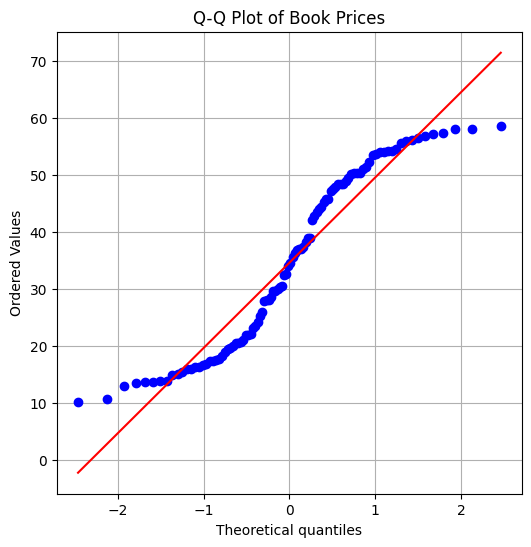

In [22]:
plt.figure(figsize=(6,6))
stats.probplot(df["Price"], dist="norm", plot=plt)
plt.title("Q-Q Plot of Book Prices")
plt.grid()
plt.show()

In [23]:
stat, p = shapiro(df["Price"])

print("Statistic:", stat)
print("p-value:", p)

Statistic: 0.9157521190091416
p-value: 8.435834773147113e-06


# Conclusion

The Q-Q plot shows deviation from the straight line, indicating that the data is not normally distributed.
The Shapiro-Wilk test also confirms this as p-value < 0.05.

In [24]:
quotes = []

for page in range(1, 11):
    url = f"http://quotes.toscrape.com/page/{page}/"

    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    quote_blocks = soup.find_all("span", class_="text")

    for q in quote_blocks:
        quotes.append(q.text)

len(quotes)

100

In [25]:
vectorizer = CountVectorizer(stop_words="english")
X = vectorizer.fit_transform(quotes)

word_counts = np.sum(X.toarray(), axis=0)
words = vectorizer.get_feature_names_out()

top5_idx = word_counts.argsort()[-5:][::-1]

top5_words = [(words[i], word_counts[i]) for i in top5_idx]
top5_words

[('love', np.int64(23)),
 ('think', np.int64(12)),
 ('life', np.int64(12)),
 ('make', np.int64(10)),
 ('don', np.int64(9))]

In [26]:
df_quotes = pd.DataFrame(X.toarray(), columns=words)
df_quotes.head()

,000,10,abilities,absolutely,absurdities,accept,act,actually,admiration,admit,...,worth,worthy,wrap,write,writing,written,wrote,wrung,year,youer
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# CountVectorizer ignores word order and context, so it cannot understand the meaning of sentences.